<a href="https://colab.research.google.com/github/phoebegunawan/Phoebe_INFO4670_Spring2026/blob/main/Logistic_Regression_Car_Assignment_Gunawan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [36]:
#Please write the code here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


In [37]:
from google.colab import files
files.upload()

Saving car_purchase_data.csv to car_purchase_data (1).csv


{'car_purchase_data (1).csv': b'User ID,Gender,Age,Salary,Purchased\r\n15624510,Male,19,19000,0\r\n15810944,Male,35,20000,0\r\n15668575,Female,26,43000,0\r\n15603246,Female,27,57000,0\r\n15804002,Male,19,76000,0\r\n15728773,Male,27,58000,0\r\n15598044,Female,27,84000,0\r\n15694829,Female,32,150000,1\r\n15600575,Male,25,33000,0\r\n15727311,Female,35,65000,0\r\n15570769,Female,26,80000,0\r\n15606274,Female,26,52000,0\r\n15746139,Male,20,86000,0\r\n15704987,Male,32,18000,0\r\n15628972,Male,18,82000,0\r\n15697686,Male,29,80000,0\r\n15733883,Male,47,25000,1\r\n15617482,Male,45,26000,1\r\n15704583,Male,46,28000,1\r\n15621083,Female,48,29000,1\r\n15649487,Male,45,22000,1\r\n15736760,Female,47,49000,1\r\n15714658,Male,48,41000,1\r\n15599081,Female,45,22000,1\r\n15705113,Male,46,23000,1\r\n15631159,Male,47,20000,1\r\n15792818,Male,49,28000,1\r\n15633531,Female,47,30000,1\r\n15744529,Male,29,43000,0\r\n15669656,Male,31,18000,0\r\n15581198,Male,31,74000,0\r\n15729054,Female,27,137000,1\r\n1557345

In [38]:
dataset = pd.read_csv("car_purchase_data.csv")
dataset.head()

,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


### Step 2: Split features and target

In [39]:
#Please write the code here
#independent variable
X = dataset[["Age", "Salary"]]
# dependent variable
y = dataset["Purchased"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())

X shape: (400, 2)
y shape: (400,)
   Age  Salary
0   19   19000
1   35   20000
2   26   43000
3   27   57000
4   19   76000


### Step 3: Train/Test Split

In [40]:
#Please write the code here
#training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
#prining the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (300, 2)
X_test shape: (100, 2)
y_train shape: (300,)
y_test shape: (100,)


### Step 4: Feature Scaling

In [41]:

sc = StandardScaler()

#scaler to fit only on the training data
X_train = sc.fit_transform(X_train)

# scaler to transform the data
X_test = sc.transform(X_test)
print("Scaled training data (first 5 rows):")
print(X_train[:5])

Scaled training data (first 5 rows):
[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]]


### Step 5: Train Logistic Regression Model

In [42]:
#Please write the code here
#creating the logistics regresion model
classifier = LogisticRegression(random_state=0)

#traing the model using the data
classifier.fit(X_train, y_train)
#premeters
print("Intercept (bias):", classifier.intercept_)
print("Coefficients (weights for Age & Salary):", classifier.coef_)

Intercept (bias): [-0.95217247]
Coefficients (weights for Age & Salary): [[2.07665837 1.11008221]]


### Step 6: Predict and Evaluate

In [43]:
#Please write the code here
# Use the trained model to predict outcomes on test data
y_pred = classifier.predict(X_test)

# Display first 10 predictions
print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[0 0 0 0 0 0 0 1 0 1]


In [44]:
#Please write the code here
cm = confusion_matrix(y_test, y_pred)

#calc the acuracy score
acc = accuracy_score(y_test, y_pred)

#results
print("Confusion Matrix:")
print(cm)
print("\nAccuracy:")
print(acc)
print("\nDetailes for the Classification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[65  3]
 [ 8 24]]

Accuracy:
0.89

Detailes for the Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100



### Step 7: Visualization of Decision Regions

/tmp/ipykernel_383/1386328425.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


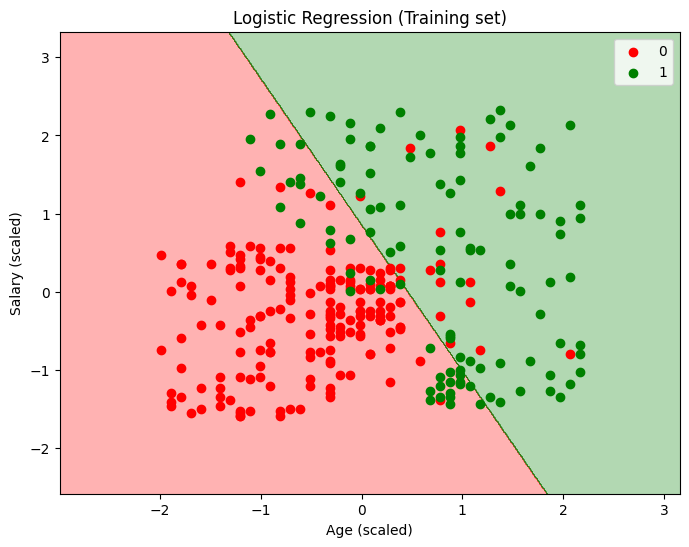

In [45]:
# plot decisions
X_set, y_set = X_train, y_train.values

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

#plotting the boundaries
plt.figure(figsize=(8,6))
plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.3,
    cmap=ListedColormap(("red", "green"))
)

#plotting the actual training points
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],

        c=ListedColormap(("red", "green"))(i),
        label=j
    )

#labeling and title
plt.title("Logistic Regression (Training set)")
plt.xlabel("Age (scaled)")
plt.ylabel("Salary (scaled)")
plt.legend()
plt.show()

/tmp/ipykernel_383/1352897745.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


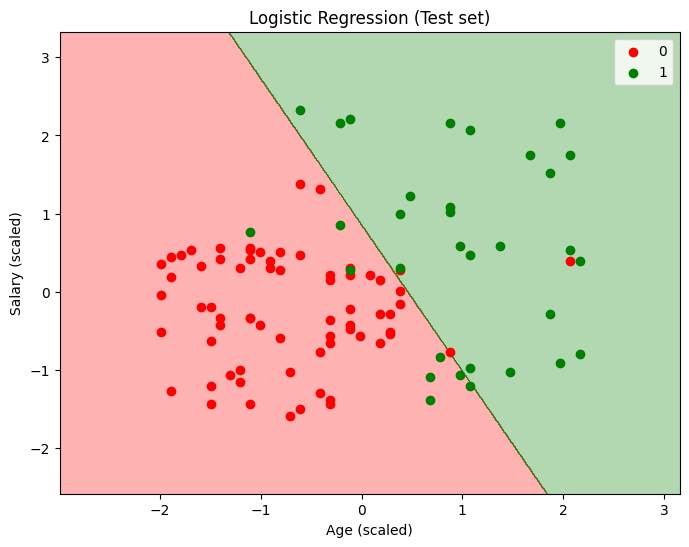

In [46]:
#same as above but test set
X_set, y_set = X_test, y_test.values

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.figure(figsize=(8,6))
plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.3,
    cmap=ListedColormap(("red", "green"))
)

#plotting the tst points
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=ListedColormap(("red", "green"))(i),
        label=j
    )

plt.title("Logistic Regression (Test set)")
plt.xlabel("Age (scaled)")
plt.ylabel("Salary (scaled)")
plt.legend()
plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1. we can use logistic regression outputs as probabilites becaause we can use it as an classification. if we set a threshold for examples as .5 we can predic the probability is greater than or equal to .5, so we classify it as 1 which is purchase, if it is less than .5 we classify it as 0 not purchased

2. customers that are more likely to purchase a car are older and have higher salries. The customers are mostly in the green region which is 1. while younger customers with a lower salary fall in the red region 0.

3. The model has low accuracy because of the fact that some data points do overlap. We some some red dots also with green dot. which can cause inaccurate prediciton.

4. some additional features they can add is credit score because it has something to do with purchasing of a vehicle and somehow add that to the model.